In [1]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.3.1+cu121
0.18.1+cu121


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary


try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4162, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 4162 (delta 53), reused 87 (delta 30), pack-reused 4035 (from 1)
Receiving objects: 100% (4162/4162), 650.89 MiB | 40.38 MiB/s, done.
Resolving deltas: 100% (2424/2424), done.
Updating files: 100% (248/248), done.


In [3]:
device  = "cuda"if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
IMG_SIZE  =  224

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
])
print({manual_transforms})

{Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)}


In [7]:
BATCH_SIZE = 32

train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

train_dataloader,test_dataloader,class_names

(<torch.utils.data.dataloader.DataLoader at 0x7aa4fd0cd600>,
 ['pizza', 'steak', 'sushi'])

In [8]:
image_batch,label_batch=next(iter(train_dataloader))
image,label=image_batch[0],label_batch[0]

image.shape,label

(torch.Size([3, 224, 224]), tensor(1))

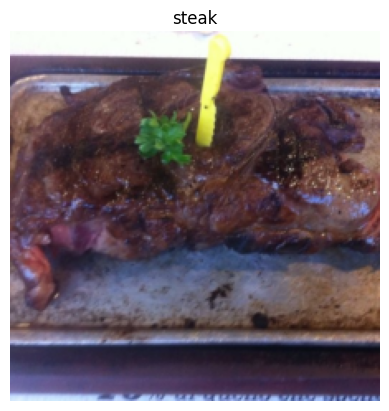

In [9]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False);


In [10]:
height = 224
width = 224
color_channels=3
patch_size=16

number_of_patches=int((height*width)/patch_size**2)

print(number_of_patches)

196


In [11]:
embedding_layer_input_shape=(height,width,color_channels)

embedding_layer_output_shape = (number_of_patches,patch_size**2*color_channels)

print(embedding_layer_output_shape)

(196, 768)


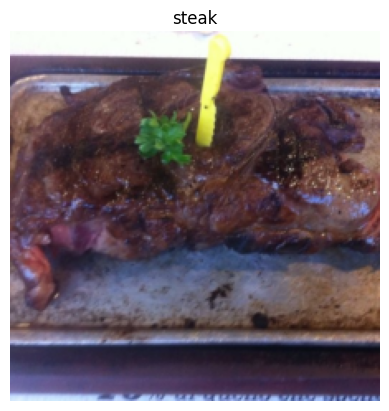

In [12]:

plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False);

In [13]:
from torch import nn

patch_size = 16

conv2d=nn.Conv2d(in_channels=3,
                 out_channels=768,
                 kernel_size=patch_size,
                 stride=patch_size,
                 padding=0)

In [14]:
image_out_conv=conv2d(image.unsqueeze(0))
print(image_out_conv.shape)

torch.Size([1, 768, 14, 14])


In [17]:
single_features_map=image_out_conv[:,0,:,:]
single_features_map,single_features_map.requires_grad

(tensor([[[-1.9673e-01, -1.8768e-01, -1.6941e-01, -1.4775e-01, -1.3406e-01,
           -1.1697e-01, -1.0309e-01, -8.1945e-02, -1.9832e-01, -1.0343e-01,
           -1.0247e-01, -1.0224e-01, -1.0019e-01, -1.0087e-01],
          [ 1.1365e-01,  1.4872e-01,  1.8331e-01,  1.6347e-01,  3.6304e-03,
           -8.3367e-03,  1.4672e-02, -9.1482e-02, -1.1294e-01,  6.5667e-02,
            9.3485e-02,  8.8518e-02,  3.6190e-02, -1.0472e-02],
          [-9.1473e-02, -1.1208e-01, -2.2940e-01, -4.9799e-02,  2.0546e-03,
           -3.0906e-02, -5.9378e-02, -6.7288e-02, -7.2609e-02, -8.7418e-02,
           -1.3020e-01, -2.1727e-01, -1.6559e-01, -6.7634e-02],
          [-7.8945e-02, -4.9972e-02, -2.4221e-02, -4.2286e-02, -9.2773e-02,
           -1.6868e-02,  3.2427e-02,  8.1052e-03, -2.4536e-04, -2.3941e-02,
           -5.8106e-02, -7.8867e-03, -2.9995e-02, -6.6357e-02],
          [-3.6919e-02, -1.5729e-02, -5.9039e-03,  5.4317e-02, -3.5734e-02,
           -1.4273e-01, -3.5901e-02, -4.1730e-02, -2.9251e-0

In [19]:
flatten=nn.Flatten(start_dim=2,
                   end_dim=3)

In [22]:
image_out_conv=conv2d(image.unsqueeze(0))
image_out_conv_flattened=flatten(image_out_conv)
print(image_out_conv_flattened.shape)

torch.Size([1, 768, 196])


In [26]:
image_out_conv_flattened_reshaped = image_out_conv_flattened.permute(0, 2, 1)
print(image_out_conv_flattened_reshaped.shape)

torch.Size([1, 196, 768])


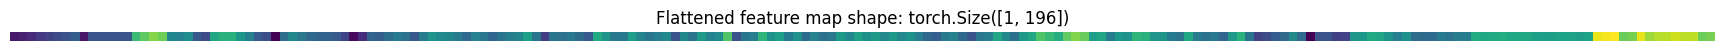

In [30]:

single_flattened_feature_map = image_out_conv_flattened_reshaped[:, :, 0]


plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);


In [31]:

single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[-1.9673e-01, -1.8768e-01, -1.6941e-01, -1.4775e-01, -1.3406e-01,
          -1.1697e-01, -1.0309e-01, -8.1945e-02, -1.9832e-01, -1.0343e-01,
          -1.0247e-01, -1.0224e-01, -1.0019e-01, -1.0087e-01,  1.1365e-01,
           1.4872e-01,  1.8331e-01,  1.6347e-01,  3.6304e-03, -8.3367e-03,
           1.4672e-02, -9.1482e-02, -1.1294e-01,  6.5667e-02,  9.3485e-02,
           8.8518e-02,  3.6190e-02, -1.0472e-02, -9.1473e-02, -1.1208e-01,
          -2.2940e-01, -4.9799e-02,  2.0546e-03, -3.0906e-02, -5.9378e-02,
          -6.7288e-02, -7.2609e-02, -8.7418e-02, -1.3020e-01, -2.1727e-01,
          -1.6559e-01, -6.7634e-02, -7.8945e-02, -4.9972e-02, -2.4221e-02,
          -4.2286e-02, -9.2773e-02, -1.6868e-02,  3.2427e-02,  8.1052e-03,
          -2.4536e-04, -2.3941e-02, -5.8106e-02, -7.8867e-03, -2.9995e-02,
          -6.6357e-02, -3.6919e-02, -1.5729e-02, -5.9039e-03,  5.4317e-02,
          -3.5734e-02, -1.4273e-01, -3.5901e-02, -4.1730e-02, -2.9251e-02,
          -5.2792e-02, -9

In [32]:
class patchembedding(nn.Module):
  def __init__(self,
               in_channels:int=3,
               patch_size:int=16,
               embedding_dim:int=786):
      super().__init__()

      self.patcher=nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0
                             )

      self.flatten=nn.Flatten(start_dim=2,
                              end_dim=3)

  def forward(self,x):
    image_resolution=x.shape[-1]
    assert image_resolution%patch_size==0

    x_patched=self.patcher(x)
    x_flattened = self.flatten(x_patched)

    return x_flattened.permute(0,2,1)

In [33]:
set_seeds()

patchify=patchembedding(in_channels=3,
                        embedding_dim=768,
                        patch_size=16)

patch_embedded_image=patchify(image.unsqueeze(0))
print(patch_embedded_image.shape)

torch.Size([1, 196, 768])


In [34]:
print(patch_embedded_image)

tensor([[[-0.9355,  0.2472, -0.1261,  ...,  0.7620, -0.5320,  0.3543],
         [-0.9281,  0.2538, -0.1423,  ...,  0.7742, -0.5274,  0.3573],
         [-0.9348,  0.2506, -0.1526,  ...,  0.7780, -0.5157,  0.3581],
         ...,
         [-0.2487,  0.1868, -0.3733,  ...,  0.3049, -0.0802,  0.0498],
         [-0.3092,  0.1162, -0.2703,  ...,  0.2338, -0.0797,  0.0878],
         [-0.2595,  0.1276, -0.2635,  ...,  0.2608, -0.1157,  0.0722]]],
       grad_fn=<PermuteBackward0>)


In [35]:
batch_size=patch_embedded_image.shape[0]
embedding_dimension=patch_embedded_image.shape[-1]

class_token=nn.Parameter(torch.ones(batch_size,1,embedding_dimension),
                         requires_grad=True)

print(class_token[:,:,:10])

print(class_token.shape)

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
torch.Size([1, 1, 768])


In [ ]:
patch_embedded_image_with_class_embedding=torch.cat((class_token,patch_embedded_))
